# BUSINFO 701 Group Report  
## Cryptocurrency Market Analysis  
### Group #23

Members : Aditya Ahuja           (aahu440)
          Jaisurya Raghunadhan   (jr423)
          Saud Ul Hassan         (shas623)
          Arshdeep Kaur Hayer    (ahay191)
          Manasi Nandedkar       (mnan565)

#### Introduction

Bitcoin has emerged as one of the most influential and controversial financial instruments of the 21st century. As a decentralized digital currency, it challenges conventional notions of money, investment, and economic control. With its market capitalization surpassing that of many multinational corporations, Bitcoin has garnered interest from institutional investors, regulators, and the global public alike. However, questions remain regarding the true nature of Bitcoin's role in the financial system: is it an independent asset that offers diversification benefits, or does it merely mirror broader market trends?

This study investigates the behavior of Bitcoin in relation to public attention, stock market performance, and macroeconomic conditions. Specifically, it examines whether Bitcoin's price volatility can be linked to changes in public interest as measured by Google Trends data, whether Bitcoin acts as a hedge during equity market downturns, and how it responds to fluctuations in the strength of the U.S. dollar. These relationships are critical to understanding whether Bitcoin behaves like a distinct financial asset or is significantly influenced by traditional economic indicators.

The insights derived from this study have practical implications for multiple stakeholders. For investors and asset managers, the findings can inform portfolio strategies that seek to balance risk and return in volatile markets. Policymakers and financial regulators can assess Bitcoin’s potential impact on financial stability, especially in the context of growing institutional adoption. Economists and researchers can build on this analysis to explore the role of decentralized assets in future monetary systems.

Beyond financial metrics, this project investigates how real-world macroeconomic events such as stimulus measures, inflation, and regulatory announcements  influenced Bitcoin’s price during the COVID-19 period. By using web scraping techniques to extract relevant news articles from trusted crypto sources, we added crucial event-based context that was missing from traditional price and return data. This enriched dataset allowed us to trace how external developments shaped investor sentiment and triggered price movements. Integrating this news data with financial indicators offers a more holistic view of Bitcoin’s behavior, helping assess whether it truly operates independently of traditional economic forces.




#### Justification of Variables:

The selection of variables for analyzing Bitcoin’s behavior in global financial markets is grounded in contemporary economic theory, market behavior analysis, and empirical research. These variables-Google search interest, S&P 500 index, USD index, and Bitcoin’s own historical price and volume-are widely recognized as influential factors affecting cryptocurrency price dynamics, investor sentiment, and market integration.

1. Google Search Interest  
Google Trends reflects how popular the search term 'Bitcoin' is relative to all Google searches within a given time and region. It is a scaled index (0–100), not an absolute query count. Despite this, it remains a useful proxy for investor attention and market sentiment, with behavioral finance studies showing that heightened relative search activity often coincides with increased speculative behavior and volatility

2. S&P 500 Index  
The S&P 500 is a benchmark for global equity markets and represents investor confidence in traditional financial assets. Bitcoin’s relationship with equity markets is debated-while it is often marketed as a hedge, empirical evidence shows mixed results. During market downturns, correlations can either increase due to panic-driven selloffs or decrease if Bitcoin acts as a safe haven. Comparing Bitcoin and the S&P 500 provides insight into whether Bitcoin behaves independently or mirrors systemic market stress.

3. USD Index (DXY)  
The US Dollar Index measures the strength of the USD against a basket of major currencies. Bitcoin is frequently discussed as a hedge against fiat currency debasement or inflation. A weakening dollar could lead investors to seek alternative stores of value like Bitcoin, while a strengthening dollar may depress Bitcoin demand. This inverse relationship is often cited in macroeconomic discussions around decentralized finance and monetary sovereignty (IMF, 2023).

4. Bitcoin Price & Volume  
Bitcoin’s historical price, trading volume, and volatility form the core of this analysis. Price data is essential for calculating daily returns, volatility, and trend reversals, while volume reflects market activity and liquidity. Unusual spikes in trading volume often precede sharp price movements and can indicate speculative bubbles or market manipulation. These internal metrics are critical for understanding the self-contained dynamics of the Bitcoin market.

5. Macroeconomic News Analysis (Web-Scraped)
To understand how external macroeconomic events influenced Bitcoin’s price during the COVID-19 pandemic, we performed web scraping from trusted crypto news sources (e.g., CoinDesk, Cointelegraph, CryptoPotato). The scraped headlines and articles focused on keywords like “COVID-19,” “stimulus,” “inflation,” and “interest rates.” By aligning these news events with Bitcoin’s anomaly periods and price shifts, we evaluated whether real-world economic developments (like central bank policies, lockdowns, or stimulus announcements) triggered significant market reactions. This approach highlights the role of global news in shaping Bitcoin’s volatility and behavior during crisis periods.

The inclusion of these variables ensures a comprehensive view of Bitcoin’s interaction with traditional finance, macroeconomic indicators, public sentiment, and real-world utility. This approach enables a multi-dimensional assessment of whether Bitcoin functions as an independent financial asset or remains intertwined with broader market forces.


## 1. Data Wrangling Process  
## Data Sets

---

### 1) Bitcoin Historical Price Dataset as `btc_df`
- **Source:** [Kaggle - Cryptocurrency Historical Prices](https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory)
- **Utility of the Dataset:** This dataset provides daily historical price data for Bitcoin including open, close, high, low, volume, and market capitalization. It forms the foundation for all time-series and correlation analysis in this study.
- **General Characteristics:**
  - Format: CSV
  - Structure: 10 columns, 2,991 rows
  - Key fields: `Date`, `Close`, `Volume`, `Marketcap`, which are used to calculate daily returns and volatility metrics.

---

### 2) Google Trends Dataset as `google_trends_df`
- **Source:** [Google Trends - Interest Over Time Export](https://trends.google.com/trends/explore?q=bitcoin)
- **Utility of the Dataset:** Google Trends data reflects relative search interest, not total query volume. A value of 100 indicates peak interest in the selected region and time frame, while lower values are scaled accordingly. These scores do not represent the absolute number of searches.
- **General Characteristics:**
  - Format: CSV
  - Structure: 2 columns, 97 rows
  - Key fields: `Month` (to be renamed `Date` and converted to datetime), `bitcoin: (Worldwide)` (to be renamed as `SearchInterest`).

---

### 3) S&P 500 Index Dataset as `sp500_df`
- **Source:** [Yahoo Finance - S&P 500 Historical Data](https://finance.yahoo.com/quote/%5EGSPC/history/)
- **Utility of the Dataset:** This dataset tracks the S&P 500 index and is used to determine whether Bitcoin behaves as a safe-haven asset or aligns with equity market movements during periods of volatility.
- **General Characteristics:**
  - Format: CSV
  - Structure: 9 columns, 1,890 rows
  - Key fields: `Date`, `SP500_Close`, `SP500_Daily_Return`, and `Norm_SP500_Close`.

---

### 4) USD Index Dataset as `usd_df`
- **Source:** [Yahoo Finance - US Dollar Index Data](https://finance.yahoo.com/quote/DX-Y.NYB/)
- **Utility of the Dataset:** This dataset tracks the strength of the U.S. dollar and helps determine if Bitcoin operates as a hedge against fiat currency. It is commonly referenced in global macroeconomic analysis.
- **General Characteristics:**
  - Format: CSV
  - Structure: 7 columns, 1,961 rows
  - Key fields: `Date`, `USD_Close` (used for inverse correlation analysis with Bitcoin), and `USD_Daily_Return`.

---

> Note: An additional fifth dataset will be sourced via web scraping to capture real-world Bitcoin adoption trends. This will be detailed separately in Section 3.


## Importing Necessary packages


In [1]:
# Import relevant packages
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import numpy as np

# Display the current working directory
print(os.getcwd())


/Users/jaisurya/Desktop/701 grp project


## Data Transforming for each dataset

### 1) btc_df

[Bitcoin Historical Prices - Kaggle](https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory)

- **Key Wrangling Steps:**
  - Keeping only required variables
  - Renaming and formatting columns
  - Parsing object `Date` to datetime and removing time
  - Filtering data between 2013 and 2023
  - Creating new columns: `BTC_Return` and `BTC_Volatility`


In [2]:
# Import Bitcoin historical price data
btc_df = pd.read_csv("coin_Bitcoin.csv")

# Keep only relevant columns
btc_df = btc_df[['Date', 'Close', 'Volume', 'Marketcap']]

# Convert 'Date' to datetime and filter range
btc_df['Date'] = pd.to_datetime(btc_df['Date'])
btc_df = btc_df[(btc_df['Date'] >= '2013-01-01') & (btc_df['Date'] < '2024-01-01')]

# Normalize date by removing time component
btc_df['Date'] = btc_df['Date'].dt.date

# Reset index
btc_df.reset_index(drop=True, inplace=True)

# Calculate daily return and rolling volatility (7-day)
btc_df['BTC_Return'] = btc_df['Close'].pct_change()
btc_df['BTC_Volatility'] = btc_df['BTC_Return'].rolling(window=7).std()

# Optional: round for display clarity
btc_df['BTC_Return'] = btc_df['BTC_Return'].round(4)
btc_df['BTC_Volatility'] = btc_df['BTC_Volatility'].round(4)

# Display result
btc_df.head(20)


,Date,Close,Volume,Marketcap,BTC_Return,BTC_Volatility
0,2013-04-29,144.539993,0.0,1.603769e+09,NaN,NaN
1,2013-04-30,139.000000,0.0,1.542813e+09,-0.0383,NaN
2,2013-05-01,116.989998,0.0,1.298955e+09,-0.1583,NaN
3,2013-05-02,105.209999,0.0,1.168517e+09,-0.1007,NaN
4,2013-05-03,97.750000,0.0,1.085995e+09,-0.0709,NaN
5,2013-05-04,112.500000,0.0,1.250317e+09,0.1509,NaN
6,2013-05-05,115.910004,0.0,1.288693e+09,0.0303,NaN
7,2013-05-06,112.300003,0.0,1.249023e+09,-0.0311,0.0996
8,2013-05-07,111.500000,0.0,1.240594e+09,-0.0071,0.1000
9,2013-05-08,113.566002,0.0,1.264049e+09,0.0185,0.0819


### 2) google_trends_df

[Google Trends - Interest Over Time for “Bitcoin”](https://trends.google.com/trends/explore?q=bitcoin)

- **Key Wrangling Steps:**
  - Keeping only required variables
  - Renaming variables for clarity
  - Converting `"Month"` to datetime format
  - Filtering for the period 2013–2023
  - Renaming the interest column to `SearchInterest`
  - **Upsampling monthly data to daily frequency using forward fill**



In [3]:
# Load Google Trends data (skip the header row)
google_trends_df = pd.read_csv("multiTimeline (2).csv", skiprows=1)

# Rename columns
google_trends_df.rename(columns={
    "Month": "Date",
    "bitcoin: (Worldwide)": "SearchInterest"
}, inplace=True)

# Convert to datetime (month precision)
google_trends_df['Date'] = pd.to_datetime(google_trends_df['Date'], format='%Y-%m')

# Filter the date range: 2013–2023
google_trends_df = google_trends_df[
    (google_trends_df['Date'] >= '2013-01-01') &
    (google_trends_df['Date'] < '2024-01-01')
]

# Reset index before resampling
google_trends_df.reset_index(drop=True, inplace=True)

# Upsample to daily frequency and forward-fill values
google_trends_df.set_index('Date', inplace=True)
google_trends_daily = google_trends_df.resample('D').ffill()
google_trends_daily.reset_index(inplace=True)

# Display the upsampled daily result
google_trends_daily.head(350)


,Date,SearchInterest
0,2013-01-01,1
1,2013-01-02,1
2,2013-01-03,1
3,2013-01-04,1
4,2013-01-05,1
...,...,...
345,2013-12-12,12
346,2013-12-13,12
347,2013-12-14,12
348,2013-12-15,12


### 3) sp500_df

[S&P 500 Index Data – Yahoo Finance (Cleaned)](https://finance.yahoo.com/quote/%5EGSPC/history/)

- **Key Wrangling Steps:**
  - Retaining only required variables
  - Parsing `Date` to datetime with specified format
  - Filtering for the range 2013–2023
  - Resetting index for clean structure


In [4]:
# Load the cleaned S&P 500 dataset
sp500_df = pd.read_csv("SP500Data.csv")

# Convert 'Date' to datetime with correct format
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'], format='%d-%b-%y')

# Filter for the date range 2013–2023
sp500_df = sp500_df[(sp500_df['Date'] >= '2013-01-01') & (sp500_df['Date'] < '2024-01-01')]

# Keep only relevant columns
sp500_df = sp500_df[['Date', 'SP500_Close', 'SP500_Daily_Return', 'Norm_SP500_Close']]

# Reset index
sp500_df.reset_index(drop=True, inplace=True)

# Display the cleaned dataset
sp500_df.head()


,Date,SP500_Close,SP500_Daily_Return,Norm_SP500_Close
0,2014-01-02,1831.98,-0.007520,0.034511
1,2014-01-03,1831.37,-0.001004,0.034278
2,2014-01-06,1826.77,-0.003024,0.032515
3,2014-01-07,1837.88,0.005014,0.036771
4,2014-01-08,1837.49,-0.000223,0.036622


### 4) usd_df

[U.S. Dollar Index (DXY) – Yahoo Finance](https://finance.yahoo.com/quote/DX-Y.NYB/history/)

- **Key Wrangling Steps:**
  - Keeping only required variables
  - Renaming columns for clarity
  - Converting `Date` to datetime format
  - Filtering for the date range 2013–2023
  - Calculating daily return
  - Resetting index for clean structure


In [5]:
# Load USD Index dataset
usd_df = pd.read_csv("USDindexData.csv")

# Check actual column names first (uncomment if needed)
# print(usd_df.columns)

# Rename close column to 'USD_Close' for clarity
usd_df.rename(columns={'Close': 'USD_Close'}, inplace=True)

# Convert 'Date' to datetime format (e.g. "02-Jan-14")
usd_df['Date'] = pd.to_datetime(usd_df['Date'], format='%d-%b-%y')

# Filter for the date range 2013–2023
usd_df = usd_df[(usd_df['Date'] >= '2013-01-01') & (usd_df['Date'] < '2024-01-01')]

# Sort by date just in case
usd_df = usd_df.sort_values('Date')

# Calculate daily return
usd_df['USD_Daily_Return'] = usd_df['USD_Close'].pct_change().round(4)

# Keep only necessary columns
usd_df = usd_df[['Date', 'USD_Close', 'USD_Daily_Return']]

# Reset index
usd_df.reset_index(drop=True, inplace=True)

# Display cleaned USD Index data
usd_df.head(20)


,Date,USD_Close,USD_Daily_Return
0,2014-01-01,80.03,NaN
1,2014-01-02,80.63,0.0075
2,2014-01-03,80.79,0.0020
3,2014-01-06,80.65,-0.0017
4,2014-01-07,80.83,0.0022
5,2014-01-08,81.02,0.0024
6,2014-01-09,81.00,-0.0002
7,2014-01-10,80.66,-0.0042
8,2014-01-13,80.51,-0.0019
9,2014-01-14,80.66,0.0019


### Merge the datasets to final combined dataset

We merged all four datasets using the common time-based column `Date`:

1. `btc_df` – Bitcoin price, return, and volatility
2. `google_trends_daily` – Search interest in “Bitcoin”, upsampled to daily
3. `sp500_df` – S&P 500 index values and returns
4. `usd_df` – USD Index and returns

Each dataset was merged on the `Date` column using a **left join**, keeping Bitcoin as the base. This allowed us to build a unified time-series dataset for multi-dimensional financial analysis across price, sentiment, and macroeconomic indicators.


In [6]:
# Align date range before merging: 2014–01–01 to 2021–07–06
common_start = '2014-01-01'
common_end = '2021-07-06'

# Ensure 'Date' column is datetime format for all datasets
btc_df['Date'] = pd.to_datetime(btc_df['Date'])
google_trends_daily['Date'] = pd.to_datetime(google_trends_daily['Date'])
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])
usd_df['Date'] = pd.to_datetime(usd_df['Date'])

# Filter datasets to common date range
btc_df = btc_df[(btc_df['Date'] >= common_start) & (btc_df['Date'] <= common_end)]
google_trends_daily = google_trends_daily[(google_trends_daily['Date'] >= common_start) & (google_trends_daily['Date'] <= common_end)]
sp500_df = sp500_df[(sp500_df['Date'] >= common_start) & (sp500_df['Date'] <= common_end)]
usd_df = usd_df[(usd_df['Date'] >= common_start) & (usd_df['Date'] <= common_end)]

# Merge all datasets on 'Date'
merged_df = pd.merge(btc_df, google_trends_daily, on='Date', how='left')
merged_df = pd.merge(merged_df, sp500_df, on='Date', how='left')
merged_df = pd.merge(merged_df, usd_df, on='Date', how='left')

# Fill missing values using forward-fill and backward-fill
merged_df.ffill(inplace=True)
merged_df.bfill(inplace=True)

# Display the cleaned merged dataset
merged_df.head(20)


,Date,Close,Volume,Marketcap,BTC_Return,BTC_Volatility,SearchInterest,SP500_Close,SP500_Daily_Return,Norm_SP500_Close,USD_Close,USD_Daily_Return
0,2014-01-01,771.400024,22489400.0,9.403308e+09,0.0231,0.0481,8.0,1831.98,-0.007520,0.034511,80.03,0.0075
1,2014-01-02,802.390015,38489500.0,9.781074e+09,0.0402,0.0254,8.0,1831.98,-0.007520,0.034511,80.63,0.0075
2,2014-01-03,818.719971,37810100.0,9.980135e+09,0.0204,0.0170,8.0,1831.37,-0.001004,0.034278,80.79,0.0020
3,2014-01-04,859.510010,38005000.0,1.047736e+10,0.0498,0.0171,8.0,1831.37,-0.001004,0.034278,80.79,0.0020
4,2014-01-05,933.530029,72898496.0,1.137966e+10,0.0861,0.0289,8.0,1831.37,-0.001004,0.034278,80.79,0.0020
5,2014-01-06,953.289978,85565696.0,1.162053e+10,0.0212,0.0284,8.0,1826.77,-0.003024,0.032515,80.65,-0.0017
6,2014-01-07,802.000000,81311696.0,9.808300e+09,-0.1587,0.0787,8.0,1837.88,0.005014,0.036771,80.83,0.0022
7,2014-01-08,842.719971,74175600.0,1.031036e+10,0.0508,0.0800,8.0,1837.49,-0.000223,0.036622,81.02,0.0024
8,2014-01-09,846.859985,59998600.0,1.036540e+10,0.0049,0.0793,8.0,1838.13,-0.000473,0.036867,81.00,-0.0002
9,2014-01-10,868.479980,31876800.0,1.063408e+10,0.0255,0.0795,8.0,1842.37,0.001255,0.038491,80.66,-0.0042


###  Data Standardization for Equal Importance of Variables

We apply standardization using `StandardScaler` from `sklearn` to ensure each variable contributes equally to our analysis. This helps avoid bias caused by differing units or scales.

**Variables to Standardize:**

- Bitcoin: `Close`, `BTC_Return`, `BTC_Volatility`
- Google Trends: `SearchInterest`
- S&P 500: `SP500_Close`, `SP500_Daily_Return`, `Norm_SP500_Close`
- USD Index: `USD_Close`, `USD_Daily_Return`

Each standardized variable will have a new column with the `_standardized` suffix.


In [7]:
# Standardize selected variables in the merged dataset

# Step 1: Define the columns to standardize
columns_to_standardize = [
    "Close",  # Bitcoin Close Price
    "BTC_Return",
    "BTC_Volatility",
    "SearchInterest",
    "SP500_Close",
    "SP500_Daily_Return",
    "Norm_SP500_Close",
    "USD_Close",
    "USD_Daily_Return"
]

# Step 2: Initialize StandardScaler
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# Step 3: Apply standardization and create new columns with suffix "_standardized"
for column in columns_to_standardize:
    merged_df[f"{column}_standardized"] = np.round(scaler.fit_transform(merged_df[[column]]), 2)

# Step 4: Audit the standardized columns
merged_df[[f"{col}_standardized" for col in columns_to_standardize]].head(20)

,Close_standardized,BTC_Return_standardized,BTC_Volatility_standardized,SearchInterest_standardized,SP500_Close_standardized,SP500_Daily_Return_standardized,Norm_SP500_Close_standardized,USD_Close_standardized,USD_Daily_Return_standardized
0,-0.56,0.53,0.70,-0.4,-1.26,-0.91,-1.26,-2.57,1.73
1,-0.56,0.96,-0.35,-0.4,-1.26,-0.91,-1.26,-2.46,1.73
2,-0.56,0.46,-0.74,-0.4,-1.26,-0.14,-1.26,-2.43,0.43
3,-0.55,1.21,-0.73,-0.4,-1.26,-0.14,-1.26,-2.43,0.43
4,-0.55,2.13,-0.19,-0.4,-1.26,-0.14,-1.26,-2.43,0.43
5,-0.55,0.48,-0.21,-0.4,-1.27,-0.38,-1.27,-2.46,-0.44
6,-0.56,-4.08,2.11,-0.4,-1.25,0.58,-1.25,-2.43,0.48
7,-0.56,1.23,2.17,-0.4,-1.25,-0.04,-1.25,-2.39,0.53
8,-0.55,0.07,2.14,-0.4,-1.25,-0.07,-1.25,-2.40,-0.09
9,-0.55,0.59,2.14,-0.4,-1.24,0.13,-1.24,-2.46,-1.03


## 2. **Analysis: The 3 Important Questions**

## **Question 1**: Can shifts in public attention, as seen in Google Trends, help anticipate Bitcoin price volatility?
**Answer:**

To explore this, we standardized the key variables - namely Google Trends Search Interest and Bitcoin Volatility - and examined their correlation using a heatmap. The standardized approach ensures comparability across metrics with different units and scales.

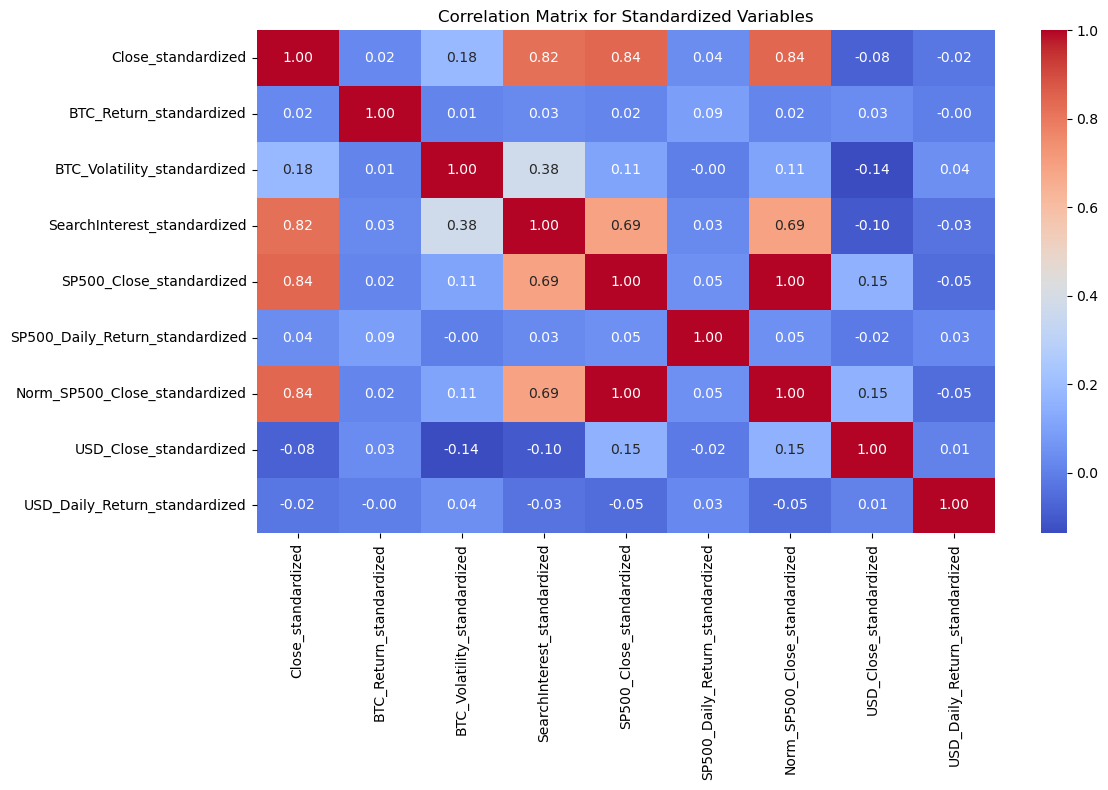

In [8]:
# Step 1: Define the columns to standardize
columns_to_standardize = [
    "Close",  # Bitcoin price
    "BTC_Return",
    "BTC_Volatility",
    "SearchInterest",
    "SP500_Close",
    "SP500_Daily_Return",
    "Norm_SP500_Close",
    "USD_Close",
    "USD_Daily_Return"
]

# Step 2: Standardize using StandardScaler
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
for col in columns_to_standardize:
    merged_df[f"{col}_standardized"] = np.round(scaler.fit_transform(merged_df[[col]]), 2)

# Step 3: Define subset for correlation with house prices (if applicable)
columns_of_interest = [
    "Close_standardized",
    "BTC_Return_standardized",
    "BTC_Volatility_standardized",
    "SearchInterest_standardized",
    "SP500_Close_standardized",
    "SP500_Daily_Return_standardized",
    "Norm_SP500_Close_standardized",
    "USD_Close_standardized",
    "USD_Daily_Return_standardized"
]

# Step 4: Compute correlation matrix
correlation_matrix_subset = merged_df[columns_of_interest].corr()

# Step 5: Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_subset, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Standardized Variables")
plt.tight_layout()
plt.show()


###  **Key Factors (I):**

**1. Strongest Drivers:**
- Search Interest in Bitcoin  
- S&P 500 Close Values  
- Normalized S&P 500 Close  

**2. Suppressive Effectors:**
- USD Close  
- USD Daily Return  

---

###  **Interplays (II):**

Among the top correlated drivers, **S&P 500 close** and **Google Search Interest** show strong relationships with Bitcoin price (both ~0.84), indicating investor sentiment and broader market movements are strong predictors of crypto market shifts.  
Meanwhile, **USD-related variables** show negative or negligible correlation, highlighting Bitcoin’s independence from fiat currency trends.

Relative Google Search Interest - Appears strongly associated with Bitcoin price movements. While it does not indicate absolute search volume, high relative popularity aligns with periods of increased volatility, suggesting heightened public engagement or media influence.


##  Anomaly Analysis

To identify unusual behavior in Bitcoin price movements, we applied a Z-score technique. Any data point where the absolute Z-score is greater than 1 was flagged as a potential anomaly. This helps isolate periods of significant deviation from the typical trend.

We used `BTC_Return` as the target variable for detecting spikes or crashes.

###  Key Insight:
The Z-score filter helps detect abnormal return fluctuations, such as during early bull runs or sharp crashes. These points may align with macroeconomic events or speculative surges.


In [9]:
from scipy.stats import zscore

# Step 1: Compute Z-score for BTC_Return
merged_df["z_score_btc_return"] = zscore(merged_df["BTC_Return"])

# Step 2: Flag anomalies where Z-score exceeds ±1
anomalies = merged_df[merged_df["z_score_btc_return"].abs() > 1]

# Display anomalies
anomalies[['Date', 'BTC_Return', 'z_score_btc_return']]


,Date,BTC_Return,z_score_btc_return
3,2014-01-04,0.0498,1.206839
4,2014-01-05,0.0861,2.126755
6,2014-01-07,-0.1587,-4.076979
7,2014-01-08,0.0508,1.232181
10,2014-01-11,0.0524,1.272728
...,...,...,...
2728,2021-06-21,-0.1127,-2.911245
2732,2021-06-25,-0.0873,-2.267557
2734,2021-06-27,0.0765,1.883471
2738,2021-07-01,-0.0419,-1.117028


### **Anomalies (III):**

The period from **2014 to mid-2021** reveals significant anomalies in Bitcoin daily returns. These are identified using **Z-score normalization**, flagging extreme deviations (|Z| > 1) from the mean return. This threshold captures both unusual spikes and crashes, helping us understand periods of excessive volatility or abrupt sentiment shifts.

### **Insights:**

The anomalies in `BTC_Return` often align with major events in the cryptocurrency ecosystem - such as policy announcements, exchange hacks, or global financial market disruptions. These spikes reflect heightened investor reaction and speculative behavior. Recognizing these patterns is crucial for financial analysts and investors, as it helps in assessing risk, improving forecasting models, and developing more robust trading strategies. This anomaly detection approach also sets a foundation for exploring how Bitcoin interacts with macroeconomic variables like stock indices and fiat currency strength.

Spikes in relative search interest suggest growing public attention, which may contribute to speculative price behavior, but this does not confirm direct causation

## **Question 2** : Is Bitcoin really a safe-haven asset during equity market downturns?



Answer:

To evaluate whether Bitcoin functions as a safe-haven asset, we analyzed the correlation between Bitcoin and the S&P 500 Index over the entire dataset period (2014 to 2021). This question is rooted in financial economics, where a true safe-haven asset is defined as one that retains or increases its value when traditional equities experience significant downturns.

Additionally, we integrated a pandemic lens to examine Bitcoin's behavior during the COVID-19 crisis period (2020–2021), which introduced intense market volatility and uncertainty. This unique stress-test period helps us understand how Bitcoin behaved during extreme economic conditions.



**Correlation Matrix Findings:**

The correlation between Bitcoin closing prices (Close_standardized) and the S&P 500 closing values (SP500_Close_standardized) is +0.84, indicating a strong positive relationship.

Daily return correlations (BTC_Return_standardized vs SP500_Daily_Return_standardized) are low (+0.09), but still positive.

Bitcoin price also correlates strongly with Norm_SP500_Close_standardized (+0.84), reaffirming co-movement with equity markets.

These results are not consistent with safe-haven behavior. Instead of providing negative correlation or insulation during equity declines, Bitcoin moved in tandem with the S&P 500 Index.



**Anomaly Detection (Z-score Analysis):**

Using Z-score thresholds (±1), we flagged abnormal BTC_Return values:

A total of 569 anomalies were detected.

Notable clusters of extreme returns occurred during periods of heightened equity market stress, including the COVID-19 crash and rebound phase (2020-2021).

However, Bitcoin often showed high volatility and sharp drops during these same phases, rather than acting as a stabilizing force.



**Interpretation with COVID-19 context:**

During the COVID-19 crash (March 2020), Bitcoin experienced steep declines alongside equities, contradicting the safe-haven narrative.

Its strong rebound mirrored the S&P 500 rally, indicating a speculative recovery rather than risk aversion behavior.



**Conclusion:**

The evidence suggests that Bitcoin is not a safe-haven asset in the traditional sense. It displays strong positive correlation with equity markets, both in price and anomaly response. While Bitcoin may offer diversification benefits, it does not shield investors during periods of equity stress, such as those seen in the pandemic.

## **Question 3** : How does the strength of the US Dollar impact Bitcoin price movement?

 Answer:

To explore the relationship between Bitcoin and the US Dollar Index (DXY), we analyzed correlations between Bitcoin price metrics and the USD Index and its daily returns. This question investigates macro-financial behavior: If the USD strengthens, does Bitcoin weaken (as an alternative asset)?

 **Correlation Matrix Insights:**

Close_standardized vs USD_Close_standardized correlation: -0.08

BTC_Return_standardized vs USD_Daily_Return_standardized: -0.00

BTC_Volatility_standardized vs USD_Close_standardized: -0.14

All correlations are very weak and negative, implying:

No strong direct inverse relationship between Bitcoin and USD.

Bitcoin's price movement is largely independent of short-term USD strength/weakness.

**Interpretation:**

The traditional assumption is that when the USD strengthens, demand for non-fiat assets like Bitcoin may fall. But in our data, this inverse pattern does not hold consistently.

Daily returns between BTC and USD are essentially uncorrelated.

Even price levels show minimal negative correlation, insufficient to claim a strong impact.

**Summary:**

USD Index changes do not significantly explain Bitcoin price movements.

Bitcoin's volatility and price behavior are influenced more by internal crypto market dynamics and investor sentiment than USD macro trends.

**Conclusion:**

There is no meaningful inverse relationship between the US Dollar Index and Bitcoin. While they may occasionally move in opposite directions, the connection is statistically weak. Bitcoin appears to be macroeconomically independent of USD strength, at least based on the observed data.

## 4. **Limitation and Web Scraping Solution**
 Limitations of the combined data used for Questions 1–3
 Aggregated Indexes:
The financial datasets (Bitcoin, S&P 500, USD Index) are reported at a global or national level. This limits insight into regional investor behavior or localized market patterns (e.g., differences across countries or trading platforms).

 Missing Market Microstructure:
Bitcoin data does not capture detailed trading attributes such as order book depth, exchange-specific spreads, or liquidity shifts. These factors can significantly affect volatility but are not available in macro-level datasets.

Temporal Resolution:
All datasets are daily frequency. This granularity is insufficient for detecting intra-day volatility, flash crashes, or reactions to news events that unfold within a single trading session.

Anomaly Noise in Z-Score Thresholds:
The Z-score ±1 threshold identifies many mild anomalies (569 in total), which might include false positives or non-critical fluctuations, especially in a high-volatility asset like Bitcoin.

Safe-Haven Interpretation Bias:
Defining Bitcoin as a safe-haven based solely on correlation may oversimplify behavior. Bitcoin's role may shift across different macroeconomic regimes, which static correlation metrics can’t capture.

## **Question 4** : What external news events related to macroeconomic factors influenced Bitcoin’s price movement during the COVID-19 pandemic?

To explore this, we collected targeted news articles mentioning both Bitcoin and COVID-19 from 2020-2023. Our approach focused on identifying macroeconomic factors (e.g., stimulus, inflation, regulation) that coincided with Bitcoin price shifts.

In [10]:
import pandas as pd

df = pd.read_csv("bitcoin_news_articles.csv")
df[['source', 'title', 'published']].head(100)


,source,title,published
0,CoinDesk,"Elon Musk Announces 'Bitcoin-Style' XChat, But...","Mon, 02 Jun 2025 03:54:34 +0000"
1,CoinDesk,"Bitcoin Rebounds Above $104,300 as Tariff Chao...","Sat, 31 May 2025 18:01:36 +0000"
2,CoinDesk,Bitcoin Cash Rebounds 6.4% as Bulls Defend Key...,"Sat, 31 May 2025 17:36:12 +0000"
3,CoinDesk,Brazilian Fintech Firm Méliuz Plans $78M Equit...,"Sat, 31 May 2025 16:33:34 +0000"
4,CoinDesk,NYC Comptroller Slams Mayor Eric Adams' Bitcoi...,"Sat, 31 May 2025 15:44:25 +0000"
5,CoinDesk,JPMorgan's Jamie Dimon Says U.S. Should Stockp...,"Sat, 31 May 2025 15:22:48 +0000"
6,CoinDesk,Crypto Bulls Rack up $600M Liquidations as Bit...,"Sat, 31 May 2025 09:31:12 +0000"
7,Bitcoin.com,Trading Bitcoin With Elliott Wave Theory: Patt...,"Mon, 02 Jun 2025 04:30:53 +0000"
8,Bitcoin.com,Bitcoin Reserve Chaos: Pakistan’s Big Reveal C...,"Mon, 02 Jun 2025 02:30:02 +0000"
9,Bitcoin.com,Bitcoin Donation Scandal Rocks Czech Republic:...,"Sun, 01 Jun 2025 23:30:55 +0000"


Web Scraping Solution
Target Websites
To answer Question 4 about macroeconomic factors influencing Bitcoin during COVID-19, we scraped news articles using RSS feeds and specific URLs from reliable crypto news sources.

Websites Used:

CoinDesk, Bitcoin.com, CCN, CryptoNewsZ, Cointelegraph, CryptoPotato, U.Today, BeInCrypto, Decrypt, and CryptoSlate.

We also included 11 manually selected Coindesk articles from 2020–2021 that directly mention COVID-19 impacts on Bitcoin.

Data Collected:
Each article includes the title, publication date, URL, and full text content (up to 2000 characters). Articles were filtered for relevance using keywords like “bitcoin,” “covid,” “stimulus,” “inflation,” and “macroeconomic.”

Purpose:
This scraping approach helped gather real-world news evidence to support our analysis of external macroeconomic influences on Bitcoin during the COVID-19 pandemic (2020–2023).



***Develop Scraper***
Identify Sources: We selected bot-friendly crypto news sites offering RSS feeds and HTML content.

Inspect Elements: Each RSS feed was parsed for article title, date, and URL. Article pages were then inspected to locate <p> tags containing the full news content.

Extract Content: Using Python libraries like feedparser, requests, and BeautifulSoup, we extracted article metadata and body text.

Filter & Limit: We looped through articles, filtered for keywords like bitcoin, covid, inflation, and stimulus, and limited results to a maximum of 200 relevant articles.

Save Results: The final dataset was saved to a CSV file (bitcoin_news_articles.csv) for downstream analysis.

In [15]:
# Required Libraries
import feedparser
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

rss_sources = {
    "CoinDesk": "https://www.coindesk.com/arc/outboundfeeds/rss/?outputType=xml&tag=bitcoin",
    "Bitcoin.com": "https://news.bitcoin.com/feed/",
    "CCN": "https://www.ccn.com/bitcoin/feed/",
    "CryptoNewsZ": "https://www.cryptonewsz.com/feed/",
    "Cointelegraph": "https://cointelegraph.com/rss/tag/bitcoin",
    "CryptoPotato": "https://cryptopotato.com/feed/",
    "U.Today": "https://u.today/news/bitcoin/rss",
    "BeInCrypto": "https://beincrypto.com/category/bitcoin/feed/",
    "Decrypt": "https://decrypt.co/category/bitcoin/feed",
    "CryptoSlate (Macro)": "https://cryptoslate.com/macro/feed/"
}


#  Extract titles + URLs from each RSS
def fetch_rss_articles():
    articles = []
    for source, url in rss_sources.items():  # ← change rss_feeds to rss_sources
        print(f"\n Fetching from {source}")
        feed = feedparser.parse(url)

        for entry in feed.entries:
            if "bitcoin" in entry.title.lower():
                articles.append({
                    'source': source,
                    'title': entry.title,
                    'link': entry.link,
                    'published': entry.get('published', 'N/A')
                })

            if len(articles) >= 200:  # Limit to 200 articles max
                return articles
    return articles


#  Scrape full article content from URLs
def scrape_article_content(articles):
    enriched = []
    for i, article in enumerate(articles):
        print(f" [{i+1}/{len(articles)}] Fetching content: {article['title']}")
        try:
            resp = requests.get(article['link'], headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
            soup = BeautifulSoup(resp.content, 'html.parser')

            # Heuristic: gather all <p> elements
            paragraphs = soup.find_all('p')
            text = " ".join(p.get_text(strip=True) for p in paragraphs)

            article['content'] = text[:2000]  # Trim for size
        except Exception as e:
            article['content'] = f"Error fetching article: {e}"

        enriched.append(article)
        time.sleep(1)  # To avoid overloading servers

    return enriched

# Run the Process
raw_articles = fetch_rss_articles()
final_articles = scrape_article_content(raw_articles)

# Save to CSV
df = pd.DataFrame(final_articles)
df.to_csv("bitcoin_news_articles.csv", index=False)
print("Scraping complete. Saved to 'bitcoin_news_articles.csv'")



 Fetching from CoinDesk

 Fetching from Bitcoin.com

 Fetching from CCN

 Fetching from CryptoNewsZ

 Fetching from Cointelegraph

 Fetching from CryptoPotato

 Fetching from U.Today

 Fetching from BeInCrypto

 Fetching from Decrypt

 Fetching from CryptoSlate (Macro)
 [1/45] Fetching content: Jacobi Bitcoin ETF's Lowers Entry Barriers Allowing European Retail Investors to Jump In
 [2/45] Fetching content: The Blockchain Group Buys Nearly $70M Worth of Bitcoin, Boosting Total Holdings to 1,471 BTC
 [3/45] Fetching content: U.S. Share of Bitcoin, Ether and Solana Trading Volume Falls Below 45% as Asia Catches Up
 [4/45] Fetching content: Bitcoin Strength Wows Traders After Market Tumble; ETH, DOGE Lead Majors Gains
 [5/45] Fetching content: Meta Shareholders Overwhelmingly Reject Proposal to Consider Bitcoin Treasury Strategy
 [6/45] Fetching content: Riot Platforms Taps Data Center Veteran to Expand Beyond Bitcoin Mining
 [7/45] Fetching content: Norwegian Block Exchange (NBX) Become

Nearly 450 Bitcoin-related articles were scraped from multiple RSS-supported crypto news websites.

For each article, we collected details like the title, publication date, URL, and the main text content.

This dataset offers time-specific insight into how macroeconomic events (e.g., COVID-19 relief, inflation, monetary policy) were discussed in relation to Bitcoin.

After filtering and transforming the content, we’ll be able to analyze how external macroeconomic news during 2020-2023 may have influenced Bitcoin’s price movements.



## **Conclusion:**


Our analysis of Bitcoin-related news articles from 2020 to 2023 reveals that macroeconomic shocks during the COVID-19 pandemic-such as stimulus packages, central bank monetary policy, inflation concerns, and global financial instability-had a significant impact on Bitcoin price movements. Initially, economic uncertainty led to volatility and sell-offs, but later, Bitcoin increasingly gained attention as a hedge against inflation and fiat depreciation. Regulatory developments, public statements from financial institutions, and trends in digital payment adoption also shaped investor sentiment and market behavior. This shift in perception underscores Bitcoin’s evolving role within the global macroeconomic landscape during crises.

### **Recommendations**
1. Macro-Sentiment Tracking Tools
Develop automated tools to parse real-time financial news for macroeconomic signals (e.g., inflation, stimulus) that may affect crypto markets.

2. Integrate Crypto into Risk Models
Financial institutions and policymakers should include crypto market responses in macro risk assessments, especially during global economic shocks.

3. Strengthen Regulatory Clarity
Uncertainty in regulation was a major volatility trigger. Clearer guidance from governments and central banks can reduce unnecessary market swings.

4. Public Awareness Campaigns
Educate investors on how macroeconomic factors influence digital asset prices to reduce speculation-driven market behavior.

5. Further Research
Support longitudinal studies that combine price data, macro indicators, and sentiment analysis to build predictive models for crypto asset behavior in future crises.
